In [11]:
import pandas as pd
import numpy as np

In [13]:
df = pd.read_csv("../data/cleaned/cleaned_procurement.csv")
df.head()


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Delivery_Missing,Delivery_Delay_Days,Savings_Per_Unit,Total_Savings,Defect_Rate
0,PO-00001,ALPHA_INC,2023-10-17,2023-10-25,OFFICE SUPPLIES,CANCELLED,1176,20.13,17.81,0.0,YES,False,8.0,2.32,2728.32,0.000000
1,PO-00002,DELTA_LOGISTICS,2022-04-25,2022-05-05,OFFICE SUPPLIES,DELIVERED,1509,39.32,37.34,235.0,YES,False,10.0,1.98,2987.82,0.155732
2,PO-00003,GAMMA_CO,2022-01-26,2022-02-15,MRO,DELIVERED,910,95.51,92.26,41.0,YES,False,20.0,3.25,2957.50,0.045055
3,PO-00004,BETA_SUPPLIES,2022-10-09,2022-10-28,PACKAGING,DELIVERED,1344,99.85,95.52,112.0,YES,False,19.0,4.33,5819.52,0.083333
4,PO-00005,DELTA_LOGISTICS,2022-09-08,2022-09-20,RAW MATERIALS,DELIVERED,1180,64.07,60.53,171.0,NO,False,12.0,3.54,4177.20,0.144915


In [14]:
df_model = df.copy()

In [15]:
df_model = df_model.drop(columns=[
    'PO_ID',
    'Supplier',
    'Item_Category',
    'Order_Status',
    'Compliance',
    'Order_Date',
    'Delivery_Date'
])

In [16]:
df_model.head()
df_model.columns

Index(['Quantity', 'Unit_Price', 'Negotiated_Price', 'Defective_Units',
       'Delivery_Missing', 'Delivery_Delay_Days', 'Savings_Per_Unit',
       'Total_Savings', 'Defect_Rate'],
      dtype='object')

In [18]:
import pandas as pd
import numpy as np

# load your cleaned procurement dataset (update path if needed)
df = pd.read_csv("../data/cleaned/cleaned_procurement.csv")

# confirm columns
print(df.columns)

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance', 'Delivery_Missing',
       'Delivery_Delay_Days', 'Savings_Per_Unit', 'Total_Savings',
       'Defect_Rate'],
      dtype='object')


In [19]:
features = [
    'Quantity',
    'Unit_Price',
    'Negotiated_Price',
    'Defective_Units',
    'Delivery_Missing',
    'Delivery_Delay_Days',
    'Savings_Per_Unit',
    'Defect_Rate'
]

target = 'Total_Savings'

df_model = df[features + [target]].copy()

df_model.head()

,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Delivery_Missing,Delivery_Delay_Days,Savings_Per_Unit,Defect_Rate,Total_Savings
0,1176,20.13,17.81,0.0,False,8.0,2.32,0.000000,2728.32
1,1509,39.32,37.34,235.0,False,10.0,1.98,0.155732,2987.82
2,910,95.51,92.26,41.0,False,20.0,3.25,0.045055,2957.50
3,1344,99.85,95.52,112.0,False,19.0,4.33,0.083333,5819.52
4,1180,64.07,60.53,171.0,False,12.0,3.54,0.144915,4177.20


In [20]:
df_model.info()
df_model.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Quantity             777 non-null    int64  
 1   Unit_Price           777 non-null    float64
 2   Negotiated_Price     777 non-null    float64
 3   Defective_Units      777 non-null    float64
 4   Delivery_Missing     777 non-null    bool   
 5   Delivery_Delay_Days  690 non-null    float64
 6   Savings_Per_Unit     777 non-null    float64
 7   Defect_Rate          777 non-null    float64
 8   Total_Savings        777 non-null    float64
dtypes: bool(1), float64(7), int64(1)
memory usage: 49.5 KB


Quantity                0
Unit_Price              0
Negotiated_Price        0
Defective_Units         0
Delivery_Missing        0
Delivery_Delay_Days    87
Savings_Per_Unit        0
Defect_Rate             0
Total_Savings           0
dtype: int64

In [21]:
# copy to avoid messing original
df_model_clean = df_model.copy()

# convert boolean → int (0/1)
df_model_clean['Delivery_Missing'] = df_model_clean['Delivery_Missing'].astype(int)

# fill missing values in Delivery_Delay_Days
df_model_clean['Delivery_Delay_Days'] = df_model_clean['Delivery_Delay_Days'].fillna(
    df_model_clean['Delivery_Delay_Days'].median()
)

# confirm
df_model_clean.isnull().sum()

Quantity               0
Unit_Price             0
Negotiated_Price       0
Defective_Units        0
Delivery_Missing       0
Delivery_Delay_Days    0
Savings_Per_Unit       0
Defect_Rate            0
Total_Savings          0
dtype: int64

In [22]:
X = df_model_clean.drop(columns=['Total_Savings'])
y = df_model_clean['Total_Savings']

print(X.shape, y.shape)

(777, 8) (777,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(621, 8) (156, 8)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 1320.7729334170185
R2: 0.8677210682043409


In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)
r2_gb = r2_score(y_test, pred_gb)

print("MAE:", mae_gb)
print("R2:", r2_gb)

MAE: 350.3732313068136
R2: 0.9667515749872765


               Feature  Importance
6     Savings_Per_Unit    0.518268
0             Quantity    0.479711
5  Delivery_Delay_Days    0.000935
1           Unit_Price    0.000419
2     Negotiated_Price    0.000279
3      Defective_Units    0.000259
7          Defect_Rate    0.000125
4     Delivery_Missing    0.000004


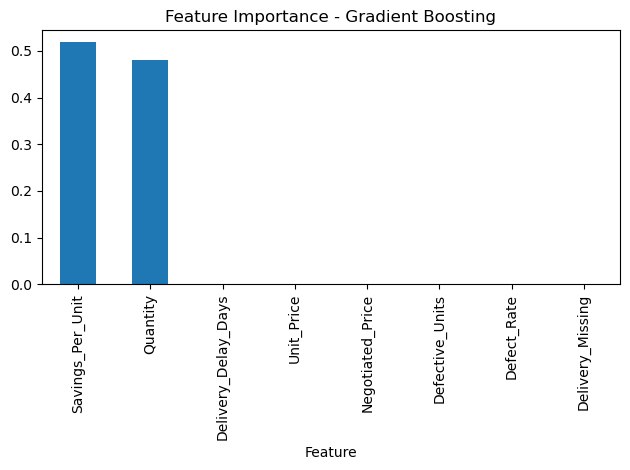

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

feature_importance.plot(
    kind='bar',
    x='Feature',
    y='Importance',
    legend=False
)
plt.title("Feature Importance - Gradient Boosting")
plt.tight_layout()
plt.show()

In [27]:
supplier_kpi = df.groupby('Supplier').agg({
    'Total_Savings': 'sum',
    'Quantity': 'sum',
    'Unit_Price': 'mean',
    'Negotiated_Price': 'mean',
    'Delivery_Delay_Days': 'mean',
    'Defective_Units': 'sum',
    'Defect_Rate': 'mean'
}).reset_index()

supplier_kpi.head()

,Supplier,Total_Savings,Quantity,Unit_Price,Negotiated_Price,Delivery_Delay_Days,Defective_Units,Defect_Rate
0,ALPHA_INC,688920.49,150414,58.386525,53.648156,10.606838,2717.0,0.018905
1,BETA_SUPPLIES,889940.89,180516,58.279423,53.607885,11.272727,13838.0,0.082723
2,DELTA_LOGISTICS,781976.49,181652,56.236023,51.898304,10.854305,19678.0,0.108666
3,EPSILON_GROUP,844980.18,180053,59.392711,54.635482,10.865772,4682.0,0.026063
4,GAMMA_CO,725308.42,157916,59.348881,54.706713,10.192308,7034.0,0.044975


In [28]:
category_kpi = df.groupby('Item_Category').agg({
    'Total_Savings': 'sum',
    'Quantity': 'sum',
    'Delivery_Delay_Days': 'mean',
    'Defect_Rate': 'mean'
}).reset_index()

category_kpi

,Item_Category,Total_Savings,Quantity,Delivery_Delay_Days,Defect_Rate
0,ELECTRONICS,742876.23,164829,11.021583,0.058092
1,MRO,902312.31,187658,11.597315,0.053427
2,OFFICE SUPPLIES,844096.16,179936,10.406667,0.063922
3,PACKAGING,732744.52,166876,10.407407,0.050525
4,RAW MATERIALS,709097.25,151252,10.341880,0.062721


In [30]:
print(df.columns)

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance', 'Delivery_Missing',
       'Delivery_Delay_Days', 'Savings_Per_Unit', 'Total_Savings',
       'Defect_Rate'],
      dtype='object')


In [32]:
import pandas as pd

df = pd.read_csv("../data/cleaned/cleaned_procurement.csv")

df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Delivery_Missing,Delivery_Delay_Days,Savings_Per_Unit,Total_Savings,Defect_Rate
0,PO-00001,ALPHA_INC,2023-10-17,2023-10-25,OFFICE SUPPLIES,CANCELLED,1176,20.13,17.81,0.0,YES,False,8.0,2.32,2728.32,0.000000
1,PO-00002,DELTA_LOGISTICS,2022-04-25,2022-05-05,OFFICE SUPPLIES,DELIVERED,1509,39.32,37.34,235.0,YES,False,10.0,1.98,2987.82,0.155732
2,PO-00003,GAMMA_CO,2022-01-26,2022-02-15,MRO,DELIVERED,910,95.51,92.26,41.0,YES,False,20.0,3.25,2957.50,0.045055
3,PO-00004,BETA_SUPPLIES,2022-10-09,2022-10-28,PACKAGING,DELIVERED,1344,99.85,95.52,112.0,YES,False,19.0,4.33,5819.52,0.083333
4,PO-00005,DELTA_LOGISTICS,2022-09-08,2022-09-20,RAW MATERIALS,DELIVERED,1180,64.07,60.53,171.0,NO,False,12.0,3.54,4177.20,0.144915


In [35]:
import pandas as pd
import numpy as np

# make sure you're using the correct dataframe
df = df.copy()

# convert correct date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# create monthly period
df['Month'] = df['Order_Date'].dt.to_period('M')

# aggregate monthly spend
monthly_spend = df.groupby('Month')['Total_Savings'].sum().reset_index()

monthly_spend.columns = ['Month', 'Total_Savings']

monthly_spend

,Month,Total_Savings
0,2022-01,144355.33
1,2022-02,131521.91
2,2022-03,184753.15
3,2022-04,171358.22
4,2022-05,90386.46
5,2022-06,152476.82
6,2022-07,127829.63
7,2022-08,175961.67
8,2022-09,164677.78
9,2022-10,172109.46


In [36]:
df_ts = monthly_spend.copy()

# ensure correct order
df_ts = df_ts.sort_values('Month')

# lag features
df_ts['Lag_1'] = df_ts['Total_Savings'].shift(1)
df_ts['Lag_2'] = df_ts['Total_Savings'].shift(2)
df_ts['Lag_3'] = df_ts['Total_Savings'].shift(3)

# rolling averages
df_ts['Rolling_3'] = df_ts['Total_Savings'].rolling(3).mean()
df_ts['Rolling_6'] = df_ts['Total_Savings'].rolling(6).mean()

# growth rate
df_ts['Growth_Rate'] = df_ts['Total_Savings'].pct_change()

df_ts

,Month,Total_Savings,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_6,Growth_Rate
0,2022-01,144355.33,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-02,131521.91,144355.33,NaN,NaN,NaN,NaN,-0.088902
2,2022-03,184753.15,131521.91,144355.33,NaN,153543.463333,NaN,0.404733
3,2022-04,171358.22,184753.15,131521.91,144355.33,162544.426667,NaN,-0.072502
4,2022-05,90386.46,171358.22,184753.15,131521.91,148832.610000,NaN,-0.472529
5,2022-06,152476.82,90386.46,171358.22,184753.15,138073.833333,145808.648333,0.686943
6,2022-07,127829.63,152476.82,90386.46,171358.22,123564.303333,143054.365000,-0.161645
7,2022-08,175961.67,127829.63,152476.82,90386.46,152089.373333,150460.991667,0.376533
8,2022-09,164677.78,175961.67,127829.63,152476.82,156156.360000,147115.096667,-0.064127
9,2022-10,172109.46,164677.78,175961.67,127829.63,170916.303333,147240.303333,0.045129


In [38]:
df_model = monthly_spend.copy()

df_model['Month'] = pd.to_datetime(df_model['Month'], errors='coerce')

df_model = df_model.sort_values('Month')

df_model

,Month,Total_Savings
0,NaT,144355.33
1,NaT,131521.91
2,NaT,184753.15
3,NaT,171358.22
4,NaT,90386.46
5,NaT,152476.82
6,NaT,127829.63
7,NaT,175961.67
8,NaT,164677.78
9,NaT,172109.46


In [39]:
df_model['Lag_1'] = df_model['Total_Savings'].shift(1)
df_model['Lag_2'] = df_model['Total_Savings'].shift(2)
df_model['Lag_3'] = df_model['Total_Savings'].shift(3)

df_model['Rolling_3'] = df_model['Total_Savings'].rolling(3).mean()
df_model['Rolling_6'] = df_model['Total_Savings'].rolling(6).mean()

df_model['Growth_Rate'] = df_model['Total_Savings'].pct_change()

df_model['Target'] = df_model['Total_Savings'].shift(-1)

df_model = df_model.dropna()

df_model

,Month,Total_Savings,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_6,Growth_Rate,Target


In [40]:
df_model.columns
df_model.shape

(0, 9)

In [42]:
df_model = monthly_spend.copy()
df_model.head()

,Month,Total_Savings
0,2022-01,144355.33
1,2022-02,131521.91
2,2022-03,184753.15
3,2022-04,171358.22
4,2022-05,90386.46


In [43]:
df_model['Month'] = df_model['Month'].astype(str)

In [44]:
df_model['Month'] = pd.to_datetime(df_model['Month'], format='%Y-%m')

In [45]:
df_model = df_model.sort_values('Month').reset_index(drop=True)
df_model.head()

,Month,Total_Savings
0,2022-01-01,144355.33
1,2022-02-01,131521.91
2,2022-03-01,184753.15
3,2022-04-01,171358.22
4,2022-05-01,90386.46


In [46]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Month          25 non-null     datetime64[ns]
 1   Total_Savings  25 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 532.0 bytes


In [47]:
df_model.head()

,Month,Total_Savings
0,2022-01-01,144355.33
1,2022-02-01,131521.91
2,2022-03-01,184753.15
3,2022-04-01,171358.22
4,2022-05-01,90386.46


In [48]:
df_model = df_model.sort_values('Month')

train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

X_train = train.drop(columns=['Total_Savings', 'Month'])
y_train = train['Total_Savings']

X_test = test.drop(columns=['Total_Savings', 'Month'])
y_test = test['Total_Savings']

print(X_train.shape, X_test.shape)

(20, 0) (5, 0)


In [51]:
X = df_model_clean[features]
y = df_model_clean['Total_Savings']

In [52]:
split = int(len(df_model_clean) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(621, 8) (156, 8)


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 1400.2193599986424
R2: 0.8278839865518762
